### Downloading and preparing the dataset

In [1]:
!pip install pandas

In [2]:
from importlib.metadata import version


pkgs = ["matplotlib",
        "numpy",
        "tiktoken",
        "torch",
        "tensorflow", # For OpenAI's pretrained weights
        "pandas"      # Dataset loading
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.1
numpy version: 2.1.3
tiktoken version: 0.7.0
torch version: 2.4.0
tensorflow version: 2.19.0
pandas version: 2.2.3


In [3]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [4]:
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
df.head(5)

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df['Label'].value_counts()

Label
ham     4825
spam     747
Name: count, dtype: int64

In [7]:
def create_balanced_dataset(df):
    
    # Count the instances of "spam"
    num_spam = df[df["Label"] == "spam"].shape[0]
    
    # Randomly sample "ham" instances to match the number of "spam" instances
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    
    # Combine ham "subset" with "spam"
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [8]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

In [9]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
# Test size is implied to be 0.2 as the remainder

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

### Creating DataLoaders

When creating data for fineutning, each training example(in a batch) should have the same length. So we can find the largest example in a batch / dataset and make it the maximum sequence length and pad all other examples to this sequence length. 

In [10]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))




[50256]


In [24]:
import torch
from torch.utils.data import Dataset

In [28]:
class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id = 50256):
        self.data = pd.read_csv(csv_file)

        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]
        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            self.encoded_texts = [encoded_text[:self.max_length] 
                                  for encoded_text in self.encoded_texts]
        
        
        self.encoded_texts = [
                encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
                for encoded_text in self.encoded_texts
            ]

    def __len__(self):
        return len(self.data)
    
    def _longest_encoded_length(self):
        return max(len(encoded_text) for encoded_text in self.encoded_texts)
    
    def __getitem__(self, idx):
        encoded = self.encoded_texts[idx]
        label = self.data["Label"][idx]
        return (torch.Tensor(encoded).long(), torch.Tensor([label]).long())

    

In [29]:
train_dataset = SpamDataset("train.csv", max_length = None, tokenizer = tokenizer)
validation_dataset = SpamDataset("validation.csv",max_length = train_dataset.max_length, tokenizer = tokenizer)
test_dataset = SpamDataset("test.csv", max_length = train_dataset.max_length, tokenizer = tokenizer)


In [30]:
from torch.utils.data import DataLoader
num_workers = 0
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size,shuffle=False, num_workers=num_workers, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size= batch_size, shuffle=False, num_workers=num_workers, drop_last=False)





In [93]:
for input_batch, label_batch in train_loader:
    print(input_batch.shape)
    print(label_batch.shape)
    break

torch.Size([8, 120])
torch.Size([8, 1])


In [33]:
print(len(train_loader))
print(len(validation_loader))
print(len(test_loader))


130
19
38


### Initialize the pretrained model

In [12]:

from gpt_download import download_and_load_gpt2

In [13]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [14]:
BASE_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'drop_rate': 0.0,
 'qkv_bias': True,
 'emb_dim': 768,
 'n_layers': 12,
 'n_heads': 12}

In [15]:
from gpt_download import download_and_load_gpt2
from full_transformer import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [20]:
from full_transformer import (
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text
)


text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you can befittingly known the, and, the, the fourthlyies


In [21]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'Ships that does not to the world-to the same amounting the same as the same asibility of the


### Putting a classification head

In [36]:
model.out_head

Linear(in_features=768, out_features=50257, bias=False)

In [38]:
for param in model.parameters():
    param.requires_grad = False
    print(param.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
Fals

In [39]:
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(BASE_CONFIG["emb_dim"], num_classes)

In [41]:
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (dropout): Dropout(p=0.0, inplace=False)
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_fe

In [50]:
for name, param in model.named_parameters():
    print(f"Layer: {name}, Shape: {param.shape}")

Layer: tok_emb.weight, Shape: torch.Size([50257, 768])
Layer: pos_emb.weight, Shape: torch.Size([1024, 768])
Layer: trf_blocks.0.att.W_query.weight, Shape: torch.Size([768, 768])
Layer: trf_blocks.0.att.W_query.bias, Shape: torch.Size([768])
Layer: trf_blocks.0.att.W_key.weight, Shape: torch.Size([768, 768])
Layer: trf_blocks.0.att.W_key.bias, Shape: torch.Size([768])
Layer: trf_blocks.0.att.W_value.weight, Shape: torch.Size([768, 768])
Layer: trf_blocks.0.att.W_value.bias, Shape: torch.Size([768])
Layer: trf_blocks.0.att.out_proj.weight, Shape: torch.Size([768, 768])
Layer: trf_blocks.0.att.out_proj.bias, Shape: torch.Size([768])
Layer: trf_blocks.0.ff.layers.0.weight, Shape: torch.Size([3072, 768])
Layer: trf_blocks.0.ff.layers.0.bias, Shape: torch.Size([3072])
Layer: trf_blocks.0.ff.layers.2.weight, Shape: torch.Size([768, 3072])
Layer: trf_blocks.0.ff.layers.2.bias, Shape: torch.Size([768])
Layer: trf_blocks.0.norm1.scale, Shape: torch.Size([768])
Layer: trf_blocks.0.norm1.shift, S

In [55]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

In [56]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [57]:
with torch.no_grad():
    outputs = model(inputs)

In [58]:
print(outputs)

tensor([[[-0.3578,  0.1009],
         [-2.5690,  7.6481],
         [-0.3159,  6.5824],
         [-1.4272,  2.0528]]])


In [69]:
outputs[:,-1]

tensor([[-1.4272,  2.0528]])

In [70]:
outputs.flatten(0,1)

tensor([[-0.3578,  0.1009],
        [-2.5690,  7.6481],
        [-0.3159,  6.5824],
        [-1.4272,  2.0528]])

In [68]:
torch.softmax(outputs[:,-1], dim = -1)

tensor(1)

### Calculating Loss and Accuracy

In [129]:
from full_transformer import calc_loss_batch, calc_loss_loader

def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0,0
    if num_batches is None:
        num_batches = len(data_loader)

    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
     
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)
            with torch.no_grad():    
                logits = model(input_batch).to(device)[:,-1,:]
            predicted_labels = torch.argmax(logits, dim = -1)
            
            num_examples += input_batch.shape[0]
            correct_predictions += (predicted_labels == target_batch.squeeze()).sum().item()
            print(predicted_labels, target_batch.squeeze())
        else:
            break
    return correct_predictions/num_examples



        


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)
train_acc = calc_accuracy_loader(train_loader, model, device, num_batches=10)
train_acc


tensor([1, 1, 1, 1, 1, 1, 1, 1]) tensor([0, 0, 1, 0, 0, 0, 1, 0])
tensor([0, 1, 1, 1, 1, 1, 1, 1]) tensor([1, 0, 1, 0, 0, 1, 0, 0])
tensor([0, 1, 1, 1, 0, 1, 1, 1]) tensor([1, 1, 0, 0, 1, 0, 1, 0])
tensor([1, 1, 1, 1, 0, 1, 1, 1]) tensor([0, 0, 1, 0, 1, 1, 0, 0])
tensor([1, 1, 0, 1, 1, 1, 1, 1]) tensor([0, 0, 1, 1, 0, 0, 1, 1])
tensor([1, 0, 1, 1, 1, 1, 1, 1]) tensor([1, 1, 0, 0, 0, 1, 0, 0])
tensor([1, 0, 1, 1, 1, 1, 1, 0]) tensor([1, 1, 0, 0, 1, 0, 1, 1])
tensor([1, 1, 1, 1, 1, 1, 1, 1]) tensor([0, 1, 1, 0, 0, 1, 1, 1])
tensor([1, 1, 1, 1, 1, 1, 1, 1]) tensor([0, 1, 0, 1, 0, 0, 1, 0])
tensor([1, 1, 1, 1, 1, 1, 1, 1]) tensor([1, 1, 1, 1, 0, 0, 1, 0])


0.3625

In [131]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)
val_acc = calc_accuracy_loader(validation_loader, model, device, num_batches=10)
val_acc


tensor([1, 1, 1, 1, 0, 1, 0, 1]) tensor([1, 1, 0, 0, 1, 0, 1, 0])
tensor([1, 1, 1, 0, 1, 1, 1, 1]) tensor([1, 0, 0, 1, 0, 1, 0, 1])
tensor([1, 1, 1, 1, 1, 1, 0, 1]) tensor([0, 1, 0, 0, 1, 0, 1, 1])
tensor([1, 1, 0, 0, 1, 1, 1, 1]) tensor([0, 1, 1, 1, 1, 0, 1, 1])
tensor([1, 1, 1, 1, 1, 1, 0, 1]) tensor([0, 0, 0, 1, 0, 0, 1, 0])
tensor([1, 1, 1, 1, 1, 1, 1, 1]) tensor([0, 0, 0, 1, 1, 0, 1, 1])
tensor([1, 1, 1, 1, 1, 1, 1, 1]) tensor([0, 0, 1, 0, 0, 1, 0, 0])
tensor([1, 1, 0, 1, 1, 1, 1, 1]) tensor([1, 0, 1, 0, 0, 1, 0, 0])
tensor([1, 1, 1, 0, 1, 1, 1, 1]) tensor([0, 1, 1, 0, 1, 0, 0, 0])
tensor([0, 1, 1, 1, 1, 1, 0, 1]) tensor([1, 1, 1, 0, 0, 0, 1, 0])


0.3375

In [132]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)
test_acc = calc_accuracy_loader(test_loader, model, device, num_batches=10)
test_acc


tensor([1, 0, 0, 1, 0, 1, 1, 1]) tensor([1, 1, 1, 0, 1, 0, 0, 1])
tensor([1, 1, 1, 1, 1, 1, 1, 1]) tensor([1, 0, 1, 1, 0, 0, 1, 0])
tensor([1, 1, 1, 1, 0, 1, 1, 1]) tensor([0, 0, 0, 1, 1, 1, 1, 0])
tensor([1, 1, 1, 1, 1, 1, 1, 1]) tensor([0, 1, 1, 1, 0, 0, 0, 1])
tensor([0, 0, 1, 1, 1, 1, 0, 1]) tensor([1, 1, 0, 1, 1, 1, 0, 0])
tensor([1, 1, 1, 0, 1, 1, 1, 1]) tensor([0, 1, 1, 1, 0, 0, 0, 0])
tensor([0, 1, 1, 1, 1, 1, 1, 0]) tensor([1, 1, 0, 1, 0, 0, 1, 1])
tensor([1, 1, 0, 0, 1, 1, 1, 1]) tensor([1, 0, 1, 0, 1, 0, 1, 0])
tensor([1, 1, 1, 1, 1, 1, 1, 1]) tensor([0, 0, 1, 1, 0, 0, 0, 0])
tensor([1, 1, 1, 1, 1, 1, 1, 1]) tensor([0, 1, 0, 0, 1, 1, 0, 0])


0.3875

In [135]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch).to(device)[:,-1,:]
    loss = torch.nn.functional.cross_entropy(logits, target_batch.squeeze())
    return loss

def calc_loss_loader(data_loader, model, device, num_batches):
    total_loss = 0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i<num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss/ num_batches

In [136]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)
train_loss = calc_loss_loader(train_loader, model, device, num_batches=10)
train_loss


1.8874373197555543

In [137]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)
validation_loss = calc_loss_loader(validation_loader, model, device, num_batches=10)
validation_loss

1.8360512852668762

In [138]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)
test_loss = calc_loss_loader(test_loader, model, device, num_batches=10)
test_loss

1.6621001720428468

### Finetuning on Supervised Dataset

In [144]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches = eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches = eval_iter
        )

        model.train()
        return train_loss, val_loss

In [147]:
def train_classifier_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs, eval_freq, 
                       eval_iter):
    train_losses, val_losses, train_accs, val_accs = [],[],[],[]
    tokens_seen, global_step = 0, -1
    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            print(input_batch.shape)
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1


            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Epoch {epoch + 1}  Step{global_step: 06d}: "
                      "Training loss: {train_loss: .3f}, Val loss: {val_loss: .3f}")
    
        train_acc = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter)
        
        val_acc = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        print(f"Epoch {epoch}: , Training Acc: {train_acc} , Val Acc: {val_acc}")
                

    return train_losses, val_losses, train_accs, val_accs, tokens_seen



In [148]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, validation_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

torch.Size([8, 120])
Epoch 1  Step000000: Training loss: {train_loss:.3f}, Val loss: {val_loss:.3f}
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120])
torch.Size([8, 120

In [152]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
    epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

ValueError: x and y must have same first dimension, but have shapes (1,) and (13,)

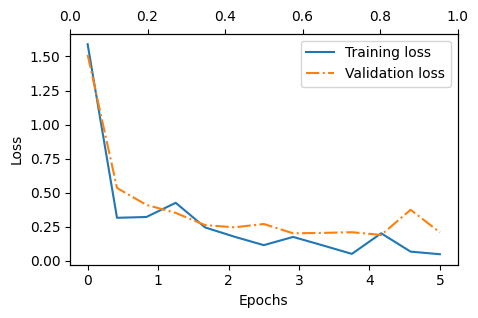

In [162]:
plot_losses(epochs_tensor, examples_seen, train_losses, val_losses)

In [155]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(validation_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

tensor([1, 0, 1, 1, 0, 0, 0, 1]) tensor([1, 0, 1, 1, 0, 0, 0, 1])
tensor([0, 1, 1, 1, 0, 1, 0, 1]) tensor([0, 1, 1, 1, 0, 1, 0, 1])
tensor([0, 1, 1, 1, 1, 1, 1, 1]) tensor([0, 1, 1, 1, 1, 1, 1, 1])
tensor([1, 1, 1, 1, 0, 1, 0, 1]) tensor([1, 1, 1, 1, 0, 1, 0, 1])
tensor([1, 0, 1, 0, 0, 0, 1, 1]) tensor([1, 0, 1, 0, 0, 0, 1, 1])
tensor([1, 1, 0, 1, 0, 1, 1, 1]) tensor([1, 1, 0, 1, 0, 1, 1, 1])
tensor([1, 0, 0, 0, 0, 1, 1, 1]) tensor([1, 0, 0, 0, 0, 1, 1, 1])
tensor([1, 0, 0, 1, 0, 1, 1, 0]) tensor([1, 0, 0, 1, 0, 1, 1, 0])
tensor([1, 1, 1, 1, 1, 1, 0, 1]) tensor([1, 1, 1, 1, 1, 1, 0, 1])
tensor([0, 0, 1, 1, 1, 1, 0, 0]) tensor([0, 0, 1, 1, 1, 1, 0, 0])
tensor([0, 1, 0, 0, 1, 0, 1, 1]) tensor([0, 1, 0, 0, 1, 0, 1, 1])
tensor([1, 0, 1, 1, 0, 0, 1, 0]) tensor([1, 0, 1, 1, 0, 0, 1, 0])
tensor([1, 0, 1, 1, 1, 1, 1, 0]) tensor([1, 0, 1, 1, 1, 1, 1, 0])
tensor([0, 1, 0, 0, 0, 1, 1, 0]) tensor([0, 1, 0, 0, 0, 1, 1, 0])
tensor([1, 0, 1, 1, 1, 1, 1, 1]) tensor([1, 0, 1, 1, 1, 1, 1, 1])
tensor([0,

In [156]:
torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict()}, "model_and_optimizer_classifier.pth")

### Doing actual text evalution 

In [157]:
def classify_text(text, model, tokenizer, max_length=None, pad_token_id = 50256):
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]
    input_ids = input_ids[:min(supported_context_length, max_length)]
    input_ids += [pad_token_id]*(max_length - len(input_ids))
    input_ids = torch.tensor(input_ids, device = device).unsqueeze(0)

    with torch.no_grad():
        logits = model(input_ids)[:,-1,:]

    predicted_label = torch.argmax(logits, dim = -1).item()

    return "spam" if predicted_label == 1 else "not spam"



In [158]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)
print(classify_text(text_1, model, tokenizer, max_length=train_dataset.max_length, pad_token_id = 50256))

spam


In [161]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_text(
    text_2, model, tokenizer, max_length=train_dataset.max_length, pad_token_id = 50256
))

not spam


### LoRA finetuning